In [1]:
import os
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.collections import LineCollection
from scipy.ndimage import gaussian_filter1d
from matplotlib import gridspec
 
# Add parent directory to sys.path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

work_path = "M:/1confiProj/"
os.chdir(work_path)
from scripts.evaluators import CompareModels, ModelEvaluator
from utils.plot_function import *
#from scripts.modelClassGPU import ConfiModel
#from scripts.modelClassGPU_old import ConfiModel as old_model
#from scripts.experiments import Experiment 

device is : cpu


# 1. General comparison between models/exps

In [54]:
exp_name1, exp_name2 = 'new_bins_no_motor3', 'new_bins_no_motor_rng3'
#exp_name1 = 'sep_prior'
CM=CompareModels(exp_name1, exp_name2)
m_lst= [2]
#m_labels = ['MA', 'MS']

In [55]:
df_ev, df_best_model = CM.compare_models(m1_list=m_lst, m2_list=m_lst, best_by='BIC', by_nll='train')

In [56]:
df_best_model

,m_id,exp,sub_id,AIC,AICc,BIC,nll,npar,best_par,nll_method,CI_readout,est_var,Causal_readout
0,2,new_bins_no_motor_rng3,2,45356.608848,45356.780909,45437.896898,22664.304424,14,"[0.849544250968814, 5.336585760116577, 4.36863...",QML,BayInt,MS,Bay
1,2,new_bins_no_motor3,3,42256.630837,42256.782504,42331.888363,21115.315419,13,"[0.9782918583270751, 4.9306793212890625, 4.762...",QML,BayInt,MS,Bay
2,2,new_bins_no_motor_rng3,5,45082.665298,45082.840079,45163.735042,22527.332649,14,"[2.6018006720990288, 3.4452694058418274, 3.039...",QML,BayInt,MS,Bay
3,2,new_bins_no_motor_rng3,6,40021.027422,40021.202204,40102.097167,19996.513711,14,"[0.2799824158167328, 0.44257211685180664, 3.30...",QML,BayInt,MS,Bay
4,2,new_bins_no_motor_rng3,11,42335.290299,42335.464862,42416.377402,21153.645149,14,"[1.050022932750466, 3.0327220261096954, 3.0356...",QML,BayInt,MS,Bay
5,2,new_bins_no_motor_rng3,15,42993.772045,42993.943894,43075.077185,21482.886022,14,"[0.8681161801813377, 5.006333351135254, 6.3034...",QML,BayInt,MS,Bay
6,2,new_bins_no_motor3,20,39840.975496,39841.128053,39916.157408,19907.487748,13,"[0.40355213203021256, 1.7699671983718872, 3.43...",QML,BayInt,MS,Bay
7,2,new_bins_no_motor3,25,44171.662436,44171.812107,44247.091157,22072.831218,13,"[0.6771541166821089, 3.2181950509548187, 4.873...",QML,BayInt,MS,Bay


In [ ]:
df_ev

In [ ]:
# two models comparison plot BIC aganist BIC
sns.scatterplot(x=df_ev.loc[(df_ev.m_id==m_lst[0]) & (df_ev.exp==exp_name1), 'BIC'].reset_index(drop=True), y=df_ev.loc[(df_ev.m_id==m_lst[1]) & (df_ev.exp==exp_name1), 'BIC'].reset_index(drop=True))
lims = [
    df_ev.BIC.min()-1000,  # lowest value across both
    df_ev.BIC.max()+1000   # highest value across both
]
plt.xlim(lims)
plt.ylim(lims)

# Add diagonal y=x line
plt.plot(lims, lims, 'k--', alpha=0.7)

plt.xlabel("BIC (interval-based)")
plt.ylabel("BIC (BCH//Estimate-based)")

plt.show()

In [ ]:
# what is improving from the BIC comparison?
df_loss_detail_m1 = CM.ev_exp1.get_loss_detail_QML(m_id=1, sub_id=2)
df_loss_detail_m2 = CM.ev_exp1.get_loss_detail_QML(m_id=2, sub_id=2)
# pre-sort by conditions for better visualization
df_loss_detail_m1 = df_loss_detail_m1.sort_values(by=['AudLoc', 'VisLoc', 'VisRel', 'blockType']).reset_index(drop=True)
df_loss_detail_m2 = df_loss_detail_m2.sort_values(by=['AudLoc', 'VisLoc', 'VisRel', 'blockType']).reset_index(drop=True)

In [ ]:
df_loss_detail_diff = df_loss_detail_m1[['AudLoc', 'VisLoc', 'VisRel', 'blockType']].copy()
df_loss_detail_diff['NLL_joint_diff'] = df_loss_detail_m1['NLL_joint'] - df_loss_detail_m2['NLL_joint']
df_loss_detail_diff['NLL_loc_diff'] = df_loss_detail_m1['NLL_loc'] - df_loss_detail_m2['NLL_loc']
df_loss_detail_diff['NLL_ci_diff'] = df_loss_detail_m1['NLL_ci'] - df_loss_detail_m2['NLL_ci']
df_loss_detail_diff

In [ ]:
df_loss_detail_diff['NLL_joint_diff'].sum(), df_loss_detail_diff['NLL_loc_diff'].sum(), df_loss_detail_diff['NLL_ci_diff'].sum()

In [ ]:
#heatmap of the differences
pivot_joint = df_loss_detail_diff.loc[(df_loss_detail_diff.blockType==1)&(df_loss_detail_diff.VisRel==1)].pivot_table(index='AudLoc', columns='VisLoc', values='NLL_joint_diff')
pivot_loc = df_loss_detail_diff.loc[(df_loss_detail_diff.blockType==1)&(df_loss_detail_diff.VisRel==1)].pivot_table(index='AudLoc', columns='VisLoc', values='NLL_loc_diff')
pivot_ci = df_loss_detail_diff.loc[(df_loss_detail_diff.blockType==1)&(df_loss_detail_diff.VisRel==1)].pivot_table(index='AudLoc', columns='VisLoc', values='NLL_ci_diff')
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
sns.heatmap(pivot_joint, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("NLL Joint Difference (Model 1 - Model 2)")
plt.subplot(1, 3, 2)
sns.heatmap(pivot_loc, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("NLL Location Difference (Model 1 - Model 2)")    
plt.subplot(1, 3, 3)
sns.heatmap(pivot_ci, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("NLL CI Difference (Model 1 - Model 2)")
plt.tight_layout()
plt.show()
            

In [ ]:
#heatmap of the differences
pivot_joint = df_loss_detail_diff.loc[(df_loss_detail_diff.blockType==1)&(df_loss_detail_diff.VisRel==2)].pivot_table(index='AudLoc', columns='VisLoc', values='NLL_joint_diff')
pivot_loc = df_loss_detail_diff.loc[(df_loss_detail_diff.blockType==1)&(df_loss_detail_diff.VisRel==2)].pivot_table(index='AudLoc', columns='VisLoc', values='NLL_loc_diff')
pivot_ci = df_loss_detail_diff.loc[(df_loss_detail_diff.blockType==1)&(df_loss_detail_diff.VisRel==2)].pivot_table(index='AudLoc', columns='VisLoc', values='NLL_ci_diff')
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
sns.heatmap(pivot_joint, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("NLL Joint Difference (Model 1 - Model 2)")
plt.subplot(1, 3, 2)
sns.heatmap(pivot_loc, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("NLL Location Difference (Model 1 - Model 2)")    
plt.subplot(1, 3, 3)
sns.heatmap(pivot_ci, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("NLL CI Difference (Model 1 - Model 2)")
plt.tight_layout()
plt.show()

In [ ]:
#heatmap of the differences
pivot_joint = df_loss_detail_diff.loc[(df_loss_detail_diff.blockType==0)&(df_loss_detail_diff.VisRel==1)].pivot_table(index='AudLoc', columns='VisLoc', values='NLL_joint_diff')
pivot_loc = df_loss_detail_diff.loc[(df_loss_detail_diff.blockType==0)&(df_loss_detail_diff.VisRel==1)].pivot_table(index='AudLoc', columns='VisLoc', values='NLL_loc_diff')
pivot_ci = df_loss_detail_diff.loc[(df_loss_detail_diff.blockType==0)&(df_loss_detail_diff.VisRel==1)].pivot_table(index='AudLoc', columns='VisLoc', values='NLL_ci_diff')
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
sns.heatmap(pivot_joint, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("NLL Joint Difference (Model 1 - Model 2)")
plt.subplot(1, 3, 2)
sns.heatmap(pivot_loc, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("NLL Location Difference (Model 1 - Model 2)")    
plt.subplot(1, 3, 3)
sns.heatmap(pivot_ci, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("NLL CI Difference (Model 1 - Model 2)")
plt.tight_layout()
plt.show()

In [ ]:
#heatmap of the differences
pivot_joint = df_loss_detail_diff.loc[(df_loss_detail_diff.blockType==0)&(df_loss_detail_diff.VisRel==2)].pivot_table(index='AudLoc', columns='VisLoc', values='NLL_joint_diff')
pivot_loc = df_loss_detail_diff.loc[(df_loss_detail_diff.blockType==0)&(df_loss_detail_diff.VisRel==2)].pivot_table(index='AudLoc', columns='VisLoc', values='NLL_loc_diff')
pivot_ci = df_loss_detail_diff.loc[(df_loss_detail_diff.blockType==0)&(df_loss_detail_diff.VisRel==2)].pivot_table(index='AudLoc', columns='VisLoc', values='NLL_ci_diff')
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
sns.heatmap(pivot_joint, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("NLL Joint Difference (Model 1 - Model 2)")
plt.subplot(1, 3, 2)
sns.heatmap(pivot_loc, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("NLL Location Difference (Model 1 - Model 2)")    
plt.subplot(1, 3, 3)
sns.heatmap(pivot_ci, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("NLL CI Difference (Model 1 - Model 2)")
plt.tight_layout()
plt.show()

In [ ]:
pivot_joint

# 2. Simulation prepare data

In [2]:
m_label = 'test_causal_bin2'
m_lst= [2]
ev=ModelEvaluator(m_label)


In [ ]:
best_param,_ =ev.get_best_param_nll(m_id=2, sub_id=2, by='train')
best_param

In [3]:
model = ev.get_model(m_id=1)
model.display_parameters()


Params for estimation are
sig_Vrh: 1
sig_Vrl: 7
sig_A: 8
kC1: 5
mC1: 1
sig_P_h: 30
sig_P_l: 30
p_com_h: 0.5
p_com_l: 0.5
rngA: 0.3
rngV: 0.3
sig_rs: 0.01
sig_rconf: 0.01
sig_rc: 0.01


In [ ]:
m_id=2
test = ev.test_model_exp(m_id)

In [14]:
df_beh = ev.dh.get_allsub_beh_data()

In [3]:
df_sim_lst = []

for m_id in m_lst:
    df_m_sim = ev.get_allsub_pred_data(m_id=m_id, save_csv=False)
    df_sim_lst.append(df_m_sim)

df_sim = pd.concat(df_sim_lst, ignore_index=True)


Model 2 subjects:   0%|          | 0/8 [00:00<?, ?subject/s]


 ------- Start Aggregating for Subject 2 ---------- 


Model 2 subjects:  12%|█▎        | 1/8 [00:00<00:04,  1.42subject/s]


 ------- Start Aggregating for Subject 3 ---------- 


Model 2 subjects:  25%|██▌       | 2/8 [00:01<00:03,  1.63subject/s]

...

Model 2 subjects:  75%|███████▌  | 6/8 [00:02<00:00,  2.14subject/s]


 ------- Start Aggregating for Subject 20 ---------- 


Model 2 subjects:  88%|████████▊ | 7/8 [00:03<00:00,  2.05subject/s]


 ------- Start Aggregating for Subject 25 ---------- 


Model 2 subjects: 100%|██████████| 8/8 [00:03<00:00,  2.01subject/s]


In [4]:
def plot_CI_size_by_condition(df, m_id=None, Modality='A'):
    
    if m_id is not None:
        #model simulation data
        df = df.loc[(df.m_id == m_id) & (df.Modality == Modality)].copy()
    else:
        #beh data
        df = df.loc[df.Modality == Modality].copy()
    df_plot = df.groupby(['sub_id', 'VisRelLabel', 'abs_delta_VA', 'AudLoc']).CISize.mean().reset_index()
    palette = sns.color_palette("viridis", as_cmap=False)

    _, axs = plt.subplots(figsize = (10, 5), nrows=1, ncols=2, sharey=True)
    sns.lineplot(
        data=df_plot[df_plot.VisRelLabel == 'High'],
        x='AudLoc',
        y='CISize',
        hue='abs_delta_VA',
        palette=palette,
        linewidth=2.5,
        ax = axs[0],
        legend = None,
        estimator = 'mean',
        errorbar='se',
        err_style='bars',
    )
    sns.lineplot(
        data=df_plot[df_plot.VisRelLabel == 'Low'],
        x='AudLoc',
        y='CISize',
        hue='abs_delta_VA',
        palette=palette,
        linewidth=2.5,
        ax = axs[1],
        estimator = 'mean',
        errorbar='se',
        err_style='bars',
        #legend = None,
    )
    clean_axs(axs[0])
    clean_axs(axs[1])

    axs[1].legend(
        title='Absolute spatial disparity ($^\\circ$)',
        frameon=False,
        loc='lower center',
        ncol=5,
        bbox_to_anchor=(0, -0.5),
        fontsize=fontsize-2,
        title_fontsize=fontsize-2
    )
    axs[0].set_title('High visual reliability', fontsize=fontsize)
    axs[1].set_title('Low visual reliability', fontsize=fontsize)
    axs[0].set_ylabel('Confidence interval', fontsize=fontsize)
    axs[0].set_xlabel('Auditory location ($^\\circ$)', fontsize=fontsize)
    axs[1].set_xlabel('Auditory location ($^\\circ$)', fontsize=fontsize)


C:\Users\wenlou\AppData\Local\Temp\ipykernel_23760\138479053.py:13: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.lineplot(
C:\Users\wenlou\AppData\Local\Temp\ipykernel_23760\138479053.py:26: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.lineplot(


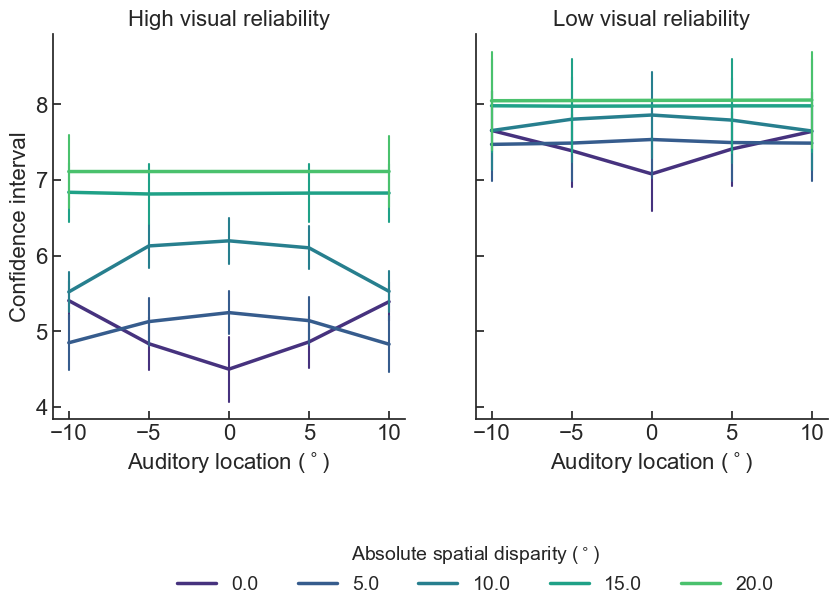

In [5]:
plot_CI_size_by_condition(df=df_sim, m_id=2) 


C:\Users\wenlou\AppData\Local\Temp\ipykernel_18064\138479053.py:13: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.lineplot(
C:\Users\wenlou\AppData\Local\Temp\ipykernel_18064\138479053.py:26: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.lineplot(


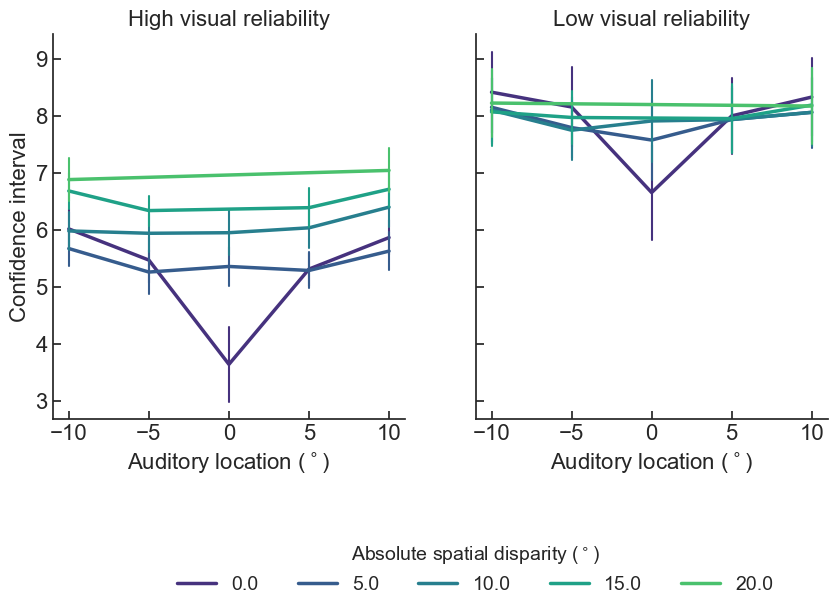

In [17]:
plot_CI_size_by_condition(df=df_beh) 

## 2. The density plots for all stimuli

In [ ]:
# sub_id = 5
ds = np.sort(df_beh.abs_delta_VA.unique())
ev_var = 'Sources'
# nsim=df_sim.loc[df_sim.model_id==1].shape[0]
title_map = {
    'report': {1: 'Auditory', 0: 'Visual'},
    'rel': {1: 'High', 2: 'Low'}
}

for sub_id in ev.exp.sub_lst_all:
    fig, axs = plt.subplots(figsize=(12, 12), ncols=5, nrows=4, sharey=True,
                            gridspec_kw={'wspace': 0.2, 'hspace': 0.4})

    # Fixed binning across all histograms (ensures same density shape each run)
    if ev_var!='Sources':
        x_min = min(df_sim[ev_var].min(), df_beh[ev_var].min())
        x_max = max(df_sim[ev_var].max(), df_beh[ev_var].max())
        bins = np.linspace(x_min, x_max, 40)

    def get_bars(df, ev_var, beh, d, ax, label,m_id=0):
        if beh:
            df_plot = df.loc[
                    (df.VisRel==rel) &
                    (df.blockType==report) &
                    (df.sub_id==sub_id) &
                    (df.abs_delta_VA==d),
                    ev_var]
        else:
            df_plot = df.loc[
                    (df.VisRel==rel) &
                    (df.blockType==report) &
                    (df.model_id==m_id) &
                    (df.sub_id==sub_id) &
                    (df.abs_delta_VA==d),
                    ev_var]
        
        if ev_var=='Sources':
            counts = df_plot.value_counts(normalize=True).sort_index()
            ax.bar(counts.index, counts.values, width = 0.25, align="edge", alpha=0.5, label=label)
        else:
            # Get counts and bin edges
            counts, edges = np.histogram(df_plot, bins=bins)
            # Normalize counts to sum to 1
            counts = counts / counts.sum()
            # Plot as bar histogram
            ax.bar(edges[:-1], counts, width=np.diff(edges), align="edge", alpha=0.5, label=label)


    for report in [0, 1]:
        for rel in [1, 2]:
            for icol, d in enumerate(ds):
                ax = axs[report*2 + rel - 1, icol]

                # interval model
                get_bars(df_sim, ev_var, 0, d, ax, m_labels[0],m_lst[0])

                # BCH model
                # get_bars(df_sim, ev_var, 0, d, ax, m_labels[1], m_lst[1])
                # get_bars(df_sim, ev_var, 0, d, ax, m_labels[2], m_lst[2])

                # behavior
                get_bars(df_beh, ev_var, 1, d, ax, 'BEH')

                ax.set_title('|sA-sV|=' + str(d))
                ax.spines[['top', 'right']].set_visible(False)

            # y-axis label only on first col
            axs[report*2 + rel - 1, 0].set_ylabel(
                f"{title_map['report'][report]} blocks,\nvisual reliability {title_map['rel'][rel]}"
            )

    # Force consistent legend
    handles, labels = axs[0,0].get_legend_handles_labels()
    #fig.legend(handles[:4], ['MA','BEH'], loc='upper right')
    fig.legend(loc='upper right') 
    fig.supylabel('Density')
    fig.suptitle('Subject ' + str(sub_id) + ' - ' + ev_var)
    plt.tight_layout()

    plt.savefig('./plots/sub_level/sub_'+str(sub_id)+'_'+ev_var+'_'+ev.exp.exp_name+'.png')
    plt.show()

## 3. Fancy David-style plots

In [ ]:
# For all subjects, the simulation plot
for visrel in ['High', 'Low']:
    plotDavidFancy(df_sim, 'bias', visrel, trial_type='A', \
                    save_fig = 1, plot_label='sim_allsub_' + m_label + '_' + visrel)

In [ ]:
for visrel in ['High', 'Low']:
    for sid in ev.exp.sub_lst_all:
        plotDavidFancy(df_sim.loc[(df_sim.sub_id==sid)&(df_sim.model_id==1)], 'bias', visrel, trial_type='A', \
                        save_fig = 1, plot_label='sim_1sub_' + str(sid) + m_label + '_' + visrel)

In [ ]:
# For all subjects, the behavioral plot
for visrel in ['High', 'Low']:
    plotDavidFancy(df_beh, 'bias', visrel, trial_type='A', \
                            save_fig = 1, plot_label='beh_allsub_' + visrel)

In [ ]:
for visrel in ['High', 'Low']:
    for sid in ev.exp.sub_lst_all:
        plotDavidFancy(df_beh.loc[(df_beh.sub_id==sid)], 'bias', visrel, trial_type='A', \
                        save_fig = 1, plot_label='beh_sub_' + str(sid) + '_' + visrel)

In [ ]:
nbin_loc=10
nbin_ci=5
nbin_ci=4
nbin_conf=8


# 4. the group pattern plots

In [6]:
m_id = 2

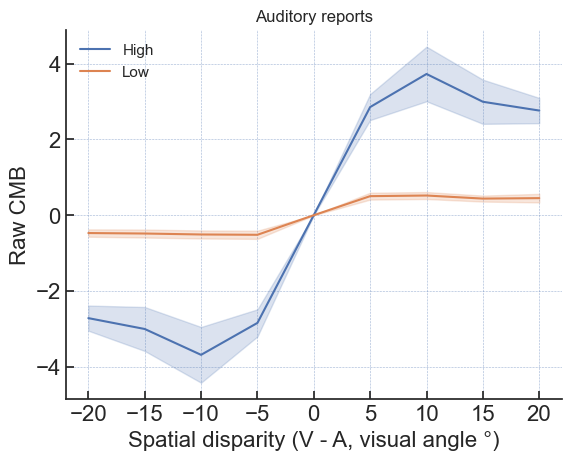

In [7]:
plot_VE(df_sim.loc[df_sim.m_id==m_id],  1)

In [ ]:
df_sim

In [ ]:
plot_VE(df_beh,  1)

In [ ]:
com_label = 'Separate'
for sub_id in ev.exp.data_handler.sub_lst_all:
    fig, axs = plt.subplots(figsize=(10, 5), ncols=2, nrows=1, sharey=True,
                        gridspec_kw={'wspace': 0.2, 'hspace': 0.4})
    plot_group_pattern(df_beh.loc[df_beh.sub_id==sub_id], 'CISize', com_label, axs[0],'A', 1, plot_name_suffix='sub_' + str(sub_id) + '_')
    plot_group_pattern(df_sim.loc[(df_sim.m_id==m_id)&(df_sim.sub_id==sub_id)], 'CISize', com_label, axs[1],'A', 1, plot_name_suffix='sub_' + str(sub_id) + '_')
    axs[0].set_title('Behavior - sub ' + str(sub_id), loc='center', fontsize=16, pad=20)
    axs[1].set_title('Model (MA) - sub ' + str(sub_id), loc='center', fontsize=16, pad=20)
    fig.suptitle('Auditory reports - '  + com_label)
    #plt.show()


AttributeError: 'Experiment' object has no attribute 'sub_lst_all'

In [ ]:
fig, axs = plt.subplots(figsize=(12, 6), ncols=3, nrows=1, sharey=True,
                        gridspec_kw={'wspace': 0.2, 'hspace': 0.4})
plot_group_pattern(df_beh, 'CISize', 'Total', axs[0],'A')
plot_group_pattern(df_beh, 'CISize', 'Total', axs[0],'A')
plot_group_pattern(df_beh, 'CISize', 'Common', axs[1],'A')
plot_group_pattern(df_beh, 'CISize', 'Separate', axs[2],'A')
axs[0].set_title('Total', loc='center', fontsize=16, pad=20)
axs[1].set_title('Common', loc='center', fontsize=16, pad=20)
axs[2].set_title('Separate', loc='center', fontsize=16, pad=20)
fig.suptitle('Auditory reports - behavior')
plt.show()

In [ ]:
fig, axs = plt.subplots(figsize=(12, 6), ncols=3, nrows=1, sharey=True,
                        gridspec_kw={'wspace': 0.2, 'hspace': 0.4})
plot_group_pattern(df_beh, 'CISize', 'Total', axs[0],'A')
plot_group_pattern(df_beh, 'CISize', 'Total', axs[0],'V')
plot_group_pattern(df_beh, 'CISize', 'Common', axs[1],'V')
plot_group_pattern(df_beh, 'CISize', 'Separate', axs[2],'V')
axs[0].set_title('Total', loc='center', fontsize=16, pad=20)
axs[1].set_title('Common', loc='center', fontsize=16, pad=20)
axs[2].set_title('Separate', loc='center', fontsize=16, pad=20)
fig.suptitle('Visual reports - behavior')
plt.show()

NameError: name 'df_beh' is not defined

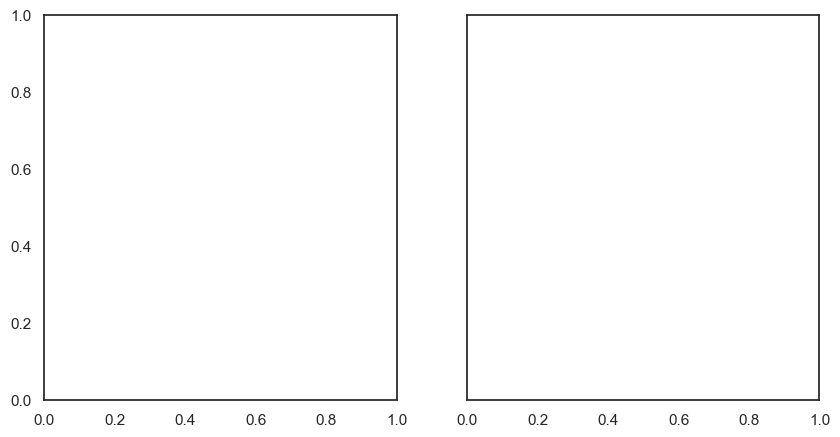

In [9]:
fig, axs = plt.subplots(figsize=(10, 5), ncols=2, nrows=1, sharey=True,
                        gridspec_kw={'wspace': 0.2, 'hspace': 0.4})
plot_group_pattern(df_beh, 'CISize', 'Total', axs[0],'A')
plot_group_pattern(df_sim.loc[df_sim.m_id==m_id], 'CISize', 'Total', axs[1],'A')
axs[0].set_title('Behavior', loc='center', fontsize=16, pad=20)
axs[1].set_title('Model (MA)', loc='center', fontsize=16, pad=20)
fig.suptitle('Auditory reports - Total')
plt.show()

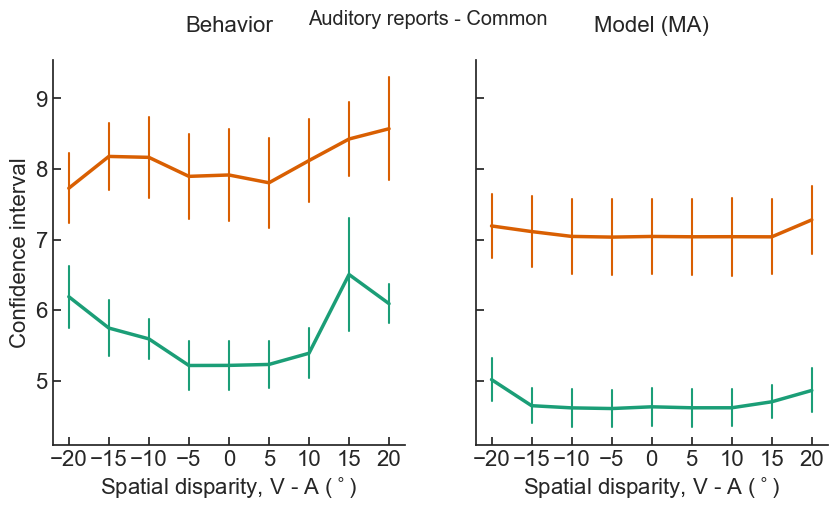

In [31]:
fig, axs = plt.subplots(figsize=(10, 5), ncols=2, nrows=1, sharey=True,
                        gridspec_kw={'wspace': 0.2, 'hspace': 0.4})
plot_group_pattern(df_beh, 'CISize', 'Common', axs[0],'A')
plot_group_pattern(df_sim.loc[df_sim.m_id==m_id], 'CISize', 'Common', axs[1],'A')
axs[0].set_title('Behavior', loc='center', fontsize=16, pad=20)
axs[1].set_title('Model (MA)', loc='center', fontsize=16, pad=20)
fig.suptitle('Auditory reports - Common')
plt.show()

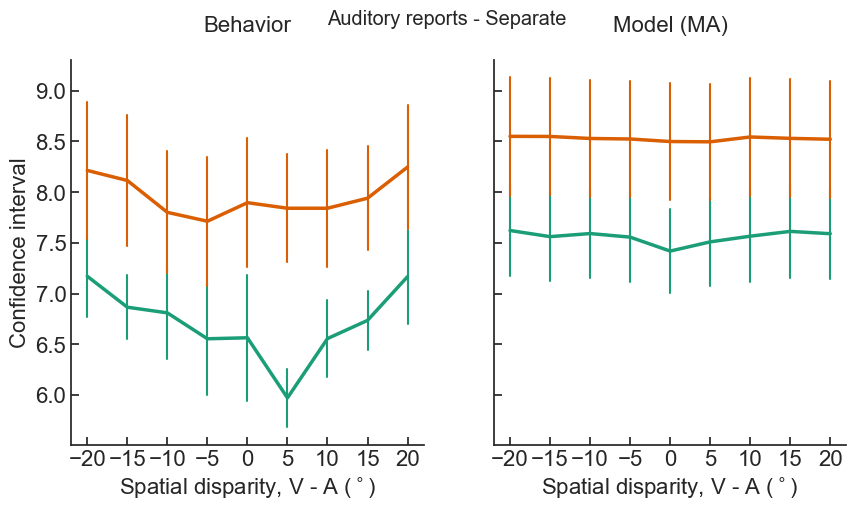

In [32]:
fig, axs = plt.subplots(figsize=(10, 5), ncols=2, nrows=1, sharey=True,
                        gridspec_kw={'wspace': 0.2, 'hspace': 0.4})
plot_group_pattern(df_beh, 'CISize', 'Separate', axs[0],'A')
plot_group_pattern(df_sim.loc[df_sim.m_id==m_id], 'CISize', 'Separate', axs[1],'A')
axs[0].set_title('Behavior', loc='center', fontsize=16, pad=20)
axs[1].set_title('Model (MA)', loc='center', fontsize=16, pad=20)
fig.suptitle('Auditory reports - Separate')
plt.show()

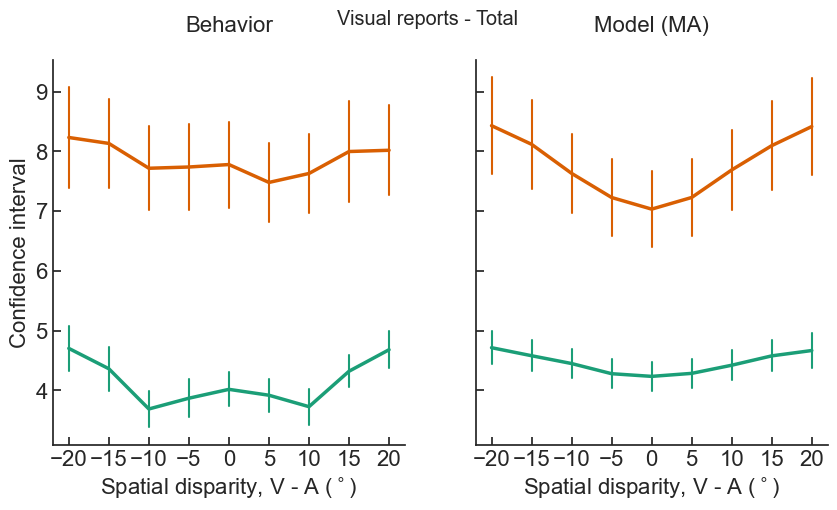

In [33]:
fig, axs = plt.subplots(figsize=(10, 5), ncols=2, nrows=1, sharey=True,
                        gridspec_kw={'wspace': 0.2, 'hspace': 0.4})
plot_group_pattern(df_beh, 'CISize', 'Total', axs[0],'V')
plot_group_pattern(df_sim.loc[df_sim.m_id==m_id], 'CISize', 'Total', axs[1],'V')
axs[0].set_title('Behavior', loc='center', fontsize=16, pad=20)
axs[1].set_title('Model (MA)', loc='center', fontsize=16, pad=20)
fig.suptitle('Visual reports - Total')
plt.show()

In [ ]:
fig, axs = plt.subplots(figsize=(10, 5), ncols=2, nrows=1, sharey=True,
                        gridspec_kw={'wspace': 0.2, 'hspace': 0.4})
plot_group_pattern(df_beh, 'CISize', 'Common', axs[0],'V')
plot_group_pattern(df_sim.loc[df_sim.m_id==m_id], 'CISize', 'Common', axs[1],'V')
axs[0].set_title('Behavior', loc='center', fontsize=16, pad=20)
axs[1].set_title('Model (MA)', loc='center', fontsize=16, pad=20)
fig.suptitle('Visual reports - Common')
plt.show()

In [ ]:
fig, axs = plt.subplots(figsize=(10, 5), ncols=2, nrows=1, sharey=True,
                        gridspec_kw={'wspace': 0.2, 'hspace': 0.4})
plot_group_pattern(df_beh, 'CISize', 'Separate', axs[0],'V')
plot_group_pattern(df_sim.loc[df_sim.m_id==m_id], 'CISize', 'Separate', axs[1],'V')
axs[0].set_title('Behavior', loc='center', fontsize=16, pad=20)
axs[1].set_title('Model (MA)', loc='center', fontsize=16, pad=20)
fig.suptitle('Visual reports - Separate')
plt.show()

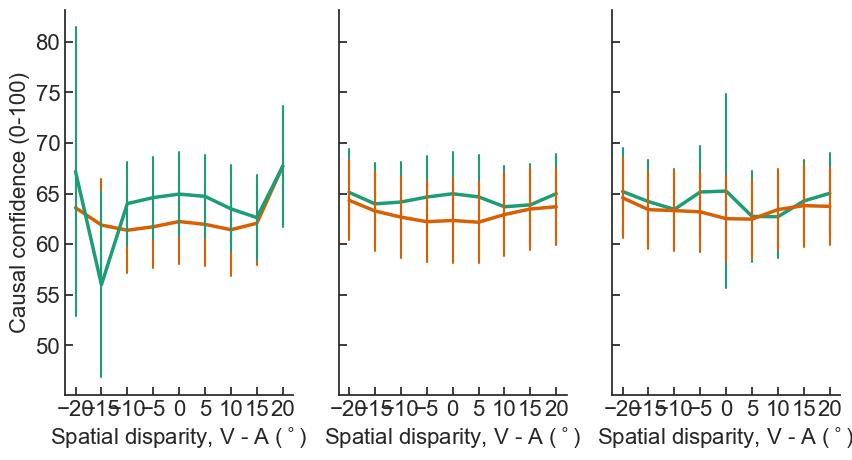

In [8]:
fig, axs = plt.subplots(figsize=(10, 5), ncols=3, nrows=1, sharey=True,
                        gridspec_kw={'wspace': 0.2, 'hspace': 0.4})
plot_group_pattern(df_sim.loc[df_sim.m_id==m_id], 'ConfLevel', 'Common', axs[0], trial_type='A')
plot_group_pattern(df_sim.loc[df_sim.m_id==m_id], 'ConfLevel', 'Total', axs[1], trial_type='A')
plot_group_pattern(df_sim.loc[df_sim.m_id==m_id], 'ConfLevel', 'Separate', axs[2], trial_type='A')

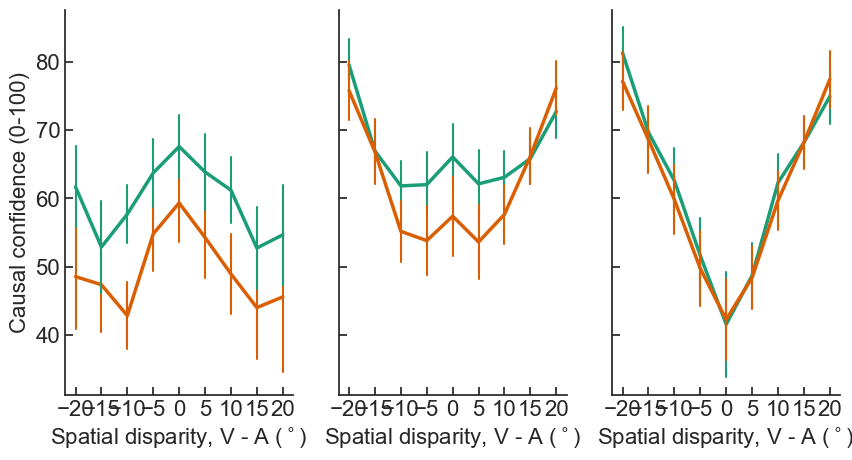

In [35]:
fig, axs = plt.subplots(figsize=(10, 5), ncols=3, nrows=1, sharey=True,
                        gridspec_kw={'wspace': 0.2, 'hspace': 0.4})
plot_group_pattern(df_beh, 'ConfLevel', 'Common', axs[0])
plot_group_pattern(df_beh, 'ConfLevel', 'Total', axs[1])
plot_group_pattern(df_beh, 'ConfLevel', 'Separate', axs[2])

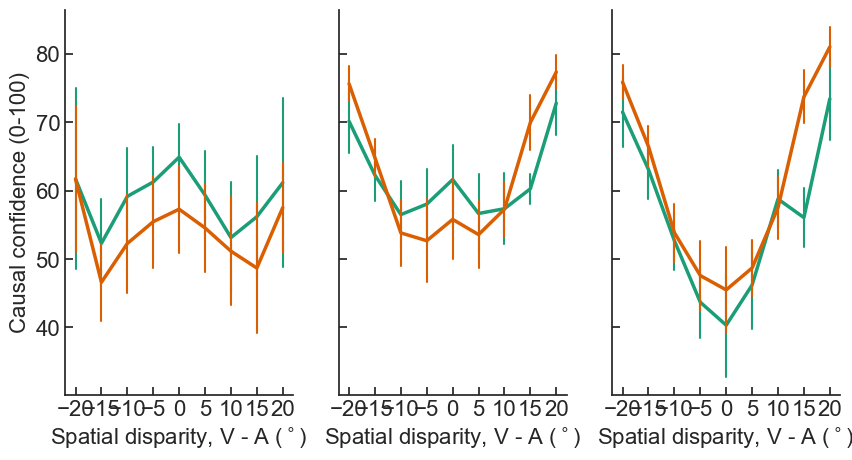

In [36]:
fig, axs = plt.subplots(figsize=(10, 5), ncols=3, nrows=1, sharey=True,
                        gridspec_kw={'wspace': 0.2, 'hspace': 0.4})
plot_group_pattern(df=df_beh, yvar='ConfLevel',com_label='Common',ax = axs[0], trial_type='V')
plot_group_pattern(df=df_beh, yvar='ConfLevel',com_label='Total',ax = axs[1], trial_type='V')
plot_group_pattern(df=df_beh, yvar='ConfLevel',com_label='Separate',ax = axs[2], trial_type='V')

## 4. NLL loss details

In [ ]:
df_loss_detail = ev.get_loss_detail_QML(m_id = m_id, sub_id = sub_id)

In [ ]:
df_loss_detail

In [ ]:
dim_name_lst = ['S_Report', 'CI', 'C', 'causal_confidence']
df_loss_detail[dim_name_lst[0]] = None
df_loss_detail[dim_name_lst[1]] = None
df_loss_detail[dim_name_lst[2]] = None
df_loss_detail[dim_name_lst[3]] = None

for irow in range(df_loss_detail.shape[0]):
    for dim in range(4):  # 4 columns
        dim_name = dim_name_lst[dim]
        beh_bins_cond = df_loss_detail.loc[irow, 'beh_bins']
        log_prob_cond = df_loss_detail.loc[irow, 'log_probs_lst']
        # Get unique bin indices for this dimension
        unique_bins = np.unique(beh_bins_cond[:,dim])
        # Sum log probs for each bin in this dimension
        bin_sums_list = []
        for bin_idx in unique_bins:
            mask = beh_bins_cond[:, dim] == bin_idx
            bin_sums_list.append(-1 * np.mean(log_prob_cond[mask]))
        
        df_loss_detail.at[irow, dim_name] = bin_sums_list


In [ ]:
df_loss_detail

In [ ]:
df_loss_detail.loc[:, ['AudLoc', 'VisLoc']].drop_duplicates().values

#### The NLL (mean) for different reports

In [ ]:
report, vrel = 1, 1
xs = np.array([-10, -5, 0, 5, 10])
fig, axs = plt.subplots(figsize=(14, 16), ncols = 5, nrows = 5, sharey=True, gridspec_kw={'wspace': 0.2, 'hspace': 0.4})
dim_idx = 0
for i_xA in range(5):
    for i_xV in range(5):
        df_subp = df_loss_detail.loc[(df_loss_detail.AudLoc == xs[i_xA]) & (df_loss_detail.VisLoc == xs[i_xV])  & (df_loss_detail.VisRel == vrel) & (df_loss_detail.blockType == report)]
        ax = axs[i_xA, i_xV]
        heights = np.array(df_subp[dim_name_lst[dim_idx]].iloc[0])  # force ndarray
        ax.bar(x=np.arange(len(heights)), height=heights)
        #ax.bar(x=range(6), height=df_subp[dim_name_lst[0]].iloc[0])
        ax.spines[['top', 'right']].set_visible(False)
        ax.set_xticks(np.arange(len(heights)))
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_title('Auditory: ' + str(xs[i_xA]) + ', Visual: ' + str(xs[i_xV]))

fig.supxlabel(dim_name_lst[dim_idx])
fig.supylabel('NLL (MEAN)')
fig.suptitle('Auditory report Blocks, visual reliability high')

plt.show()

In [ ]:
report, vrel = 1, 1
xs = np.array([-10, -5, 0, 5, 10])
fig, axs = plt.subplots(figsize=(14, 16), ncols = 5, nrows = 5, sharey=True, gridspec_kw={'wspace': 0.2, 'hspace': 0.4})
dim_idx = 2
for i_xA in range(5):
    for i_xV in range(5):
        df_subp = df_loss_detail.loc[(df_loss_detail.AudLoc == xs[i_xA]) & (df_loss_detail.VisLoc == xs[i_xV])  & (df_loss_detail.VisRel == vrel) & (df_loss_detail.blockType == report)]
        ax = axs[i_xA, i_xV]
        heights = np.array(df_subp[dim_name_lst[dim_idx]].iloc[0])  # force ndarray
        ax.bar(x=np.arange(len(heights)), height=heights)
        #ax.bar(x=range(6), height=df_subp[dim_name_lst[0]].iloc[0])
        ax.spines[['top', 'right']].set_visible(False)
        ax.set_xticks(np.arange(len(heights)))
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_title('Auditory: ' + str(xs[i_xA]) + ', Visual: ' + str(xs[i_xV]))

fig.supxlabel(dim_name_lst[dim_idx])
fig.supylabel('NLL (MEAN)')
fig.suptitle('Auditory report Blocks, visual reliability high')

plt.show()

#### The NLL (mean)  for different stimuli 

In [ ]:
df_loss_detail.loc[ df_loss_detail.VisRel==1, 'VisRelLabel'] = 'High'
df_loss_detail.loc[ df_loss_detail.VisRel==2, 'VisRelLabel'] = 'Low'

In [ ]:
# plot one condition 
fig, axs = plt.subplots(figsize=(14, 16), ncols = 5, nrows = 5, sharey=True, gridspec_kw={'wspace': 0.2, 'hspace': 0.4})
report = 1
xs = np.array([-10, -5, 0, 5, 10])

for i_xA in range(5):
    for i_xV in range(5):
        df_subp = df_loss_detail.loc[(df_loss_detail.AudLoc == xs[i_xA]) & (df_loss_detail.VisLoc == xs[i_xV]) & (df_loss_detail.blockType == report)]
        ax = axs[i_xA, i_xV]
        sns.barplot(data = df_subp, x = 'VisRelLabel', y = 'NLL', ax = ax)
        ax.spines[['top', 'right']].set_visible(False)
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_title('Auditory: ' + str(xs[i_xA]) + ', Visual: ' + str(xs[i_xV]))

fig.supxlabel('Visual Reliability')
fig.supylabel('NLL (MEAN)')
fig.suptitle('Auditory report Blocks')

plt.show()


In [ ]:
fig, axs = plt.subplots(figsize=(14, 16), ncols = 5, nrows = 5, sharey=True, gridspec_kw={'wspace': 0.2, 'hspace': 0.4})
report = 0
xs = np.array([-10, -5, 0, 5, 10])

for i_xA in range(5):
    for i_xV in range(5):
        df_subp = df_loss_detail.loc[(df_loss_detail.AudLoc == xs[i_xA]) & (df_loss_detail.VisLoc == xs[i_xV]) & (df_loss_detail.blockType == report)]
        ax = axs[i_xA, i_xV]
        sns.barplot(data = df_subp, x = 'VisRelLabel', y = 'NLL', ax = ax)
        ax.spines[['top', 'right']].set_visible(False)
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_title('Auditory: ' + str(xs[i_xA]) + ', Visual: ' + str(xs[i_xV]))



fig.supxlabel('Visual Reliability')
fig.supylabel('NLL(MEAN)')
fig.suptitle('Visual report Blocks')

plt.show()